# Micro-sam for instance segmentation

In this notebook, we want to try out automatic [instance segmentation](https://medium.com/@abhishekjainindore24/semantic-vs-instance-vs-panoptic-segmentation-b1f5023da39f) using [micro-sam](https://github.com/computational-cell-analytics/micro-sam). 

It is inspired by the [automatic-segmentation notebook in the micro-sam github repository](https://github.com/computational-cell-analytics/micro-sam/blob/master/notebooks/automatic_segmentation.ipynb) as well as two introductory notebooks written by Robert [here](https://github.com/ScaDS/BIDS-lecture-2024/blob/main/09c_micro_sam/micro-sam.ipynb) and [here](https://github.com/haesleinhuepf/micro-sam/blob/0f3e49026fce6f065f377724d12ea29b4b590017/notebooks/quick_start.ipynb).

Let us first import everything we need:

In [1]:
import h5py
from skimage.io import imread
from micro_sam import util
from micro_sam.instance_segmentation import (
    get_predictor_and_decoder,
    InstanceSegmentationWithDecoder,
    mask_data_to_segmentation
)
import matplotlib.pyplot as plt

As an example image, we use [a fluorescence microscopy dataset published by M. Arvidsson et al.](https://zenodo.org/records/6657260) showing Hoechst 33342-stained nuclei, licensed [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).

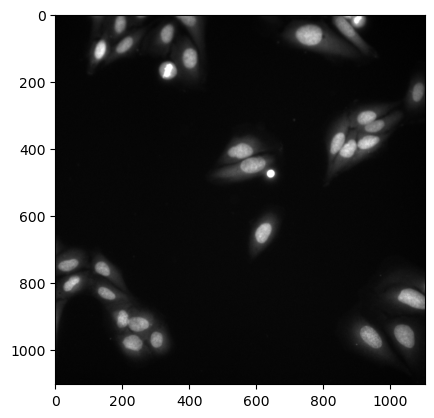

In [2]:
# Load microscopy image
image = imread("../../data/development_nuclei.png")
# Show input image
plt.imshow(image, cmap="gray")

Now, we can start working with the micro-sam library. Therefore, we define a function that runs automatic cell segmentation using a pretrained micro-sam model. It first extracts image features (embeddings) and then applies a segmentation decoder to detect individual cell instances in the image.

In [3]:
def segment_cells(image):
    predictor, decoder = get_predictor_and_decoder(
        model_type="vit_b_lm",
        checkpoint_path=None  # use default pretrained model
    )
    embeddings = util.precompute_image_embeddings(predictor, image, ndim=2)

    segmenter = InstanceSegmentationWithDecoder(predictor, decoder)
    segmenter.initialize(image=image, image_embeddings=embeddings)

    masks = segmenter.generate()
    return mask_data_to_segmentation(masks, with_background=True)

Now we can run the segmentation and visualize the results side-by-side with the input image.

In [4]:
# Run segmentation
segmentation = segment_cells(image)

Using apple MPS device.


Compute Image Embeddings 2D: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


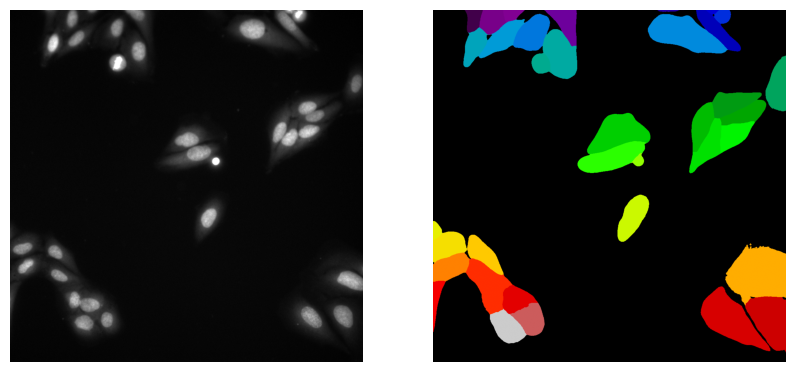

In [5]:
# show image and segmentation result side-by-sid
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(segmentation, cmap="nipy_spectral")
plt.axis("off")
plt.show()


If you want to dive further into this topic, see the [linked jupyter notebooks](https://github.com/computational-cell-analytics/micro-sam/tree/master/notebooks) as well as this [vide playlist](https://www.youtube.com/playlist?list=PLwYZXQJ3f36GQPpKCrSbHjGiH39X4XjSO).

## Exercise 

We have used the model `vit_b_lm`. Try out another one, for example `vit_b_em_organelles` which is specialized for electron microscopy and organelle segmentation. Which differences in the segmentation result can you observe and why do you think this is the case?